### Purpose
This notebook serves as the exploratory data analysis foundation for an end-to-end machine learning pipeline using CRMLS residential sales data to predict the final close price of a single-family property in California based on its characteristics at the time of the query.

### Background
As previously mentioned, the data is from California Regional Multiple Listing Service (CRMLS), a private cooperative database operated by regional association of real estate brokers.

Since we're working with real estate, it is important to contexualize the meaning of the data with a few key terms.
1. Listing: Seller signs a listing agreement with licensed agent, and agent enters ListPrice, LivingArea, BedroomsTotal, and Address fields into the MLS.
    
    1a. ListPrice: what the seller wants

    1b. ClosePrice: what the market will pay

2. Buyer Preapproval & Offers: Buyers typically obtain a mortgage preapproval letter before submitting an offer, which is based on income, credit score, and debt-to-income ratio and used as a financial qualification filter.

    2a. Compare ListPrice vs ClosePrice plus days-on-market. Downward large difference between list and close price may signal overpriced listing or deteriorating market.
3. Purchase Agreement & Escrow: Offer accepted, both parties sign purchase agreement that locks in the price, contingencies, and a closing date is agreed between both buyer and seller. Changes to "Pending" in MLS.

    3a. Contingencies: conditions that are met for the deal to proceed, which commonly include inspection, appraisal, and financing.
    
    3b. Then the escrow, neutral third-party account that holds buyer's deposit and all transaction funds, will do home inspection, appraisal, loan underwriting, title search, and final paperwork.

    3c. Data may have a property with multiple listing records or status changes. It's reflecting a real transaction that failed to close.

Data was downloaded on 9/26/2026 and the monthly data was from January 2024 to April 2026, or roughly 27 months of CRMLS data. It will be partition in this way.
| Period | Role | Use |
|---|---|---|
| Jan 2024 → Feb 2026 | **Training** | EDA, cleaning decisions, feature engineering, fit models |
| Mar 2026 | **Validation** | Hyperparameter tuning / model selection |
| Apr 2026 | **Test** | Final evaluation only |

‼️ update this: In this notebook, we will look at schema drift, ClosePrice (target value), numeric variables,  #TODO: Summarize what you did.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# first available 
df_2024_01 = pd.read_csv('dataset/CRMLSSold202401_filled.csv')
df_2024_01.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,False,NaN,NaN,93544,0.0,108883.0,NaN,False,False


In [3]:
df_2026_02 = pd.read_csv('dataset/CRMLSSold202602.csv')
df_2026_02.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
0,BayEast,Oakland,Carpet,NaN,NaN,NaN,False,1210000.0,1155025463,mike.swiderski@cbnorcal.com,...,NaN,False,2.0,NaN,94598,NaN,27600.0,NaN,CRMLS,CRMLS_BMLS
1,Newport,Newport,"Tile,Wood",True,NaN,NaN,False,3150000.0,1154998305,casey@caseyoconnorgroup.com,...,1.0,True,1.0,Newport Mesa Unified,92625,0.0,3540.0,NaN,CRMLS,CRMLS_CRM
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1154943263,ben@strockrealestate.com,...,NaN,False,2.0,Other,95032,NaN,10454.0,NaN,CRMLS,CRMLS_MLSL
3,NorthSanDiegoCounty,NorthSanDiegoCounty,Laminate,False,NaN,NaN,False,649999.0,1154868125,listings@bottrellteam.com,...,NaN,NaN,1.0,San Diego Unified,92105,0.0,5500.0,NaN,CRMLS,CRMLS_CRP
4,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,NaN,NaN,NaN,700000.0,1154785403,meriahdruliner@gmail.com,...,NaN,NaN,NaN,NaN,92070,0.0,3484800.0,NaN,CRMLS,CRMLS_CRP


##### Columns have changed over the years.

In [4]:
# Similarities: items in both sets
similar = df_2024_01.columns.intersection(df_2026_02.columns)
print("similar:", similar)

# Differences
only_in_2024 = df_2024_01.columns.difference(df_2026_02.columns)
only_in_2026 = df_2026_02.columns.difference(df_2024_01.columns)
print("only in Jan 2024:", only_in_2024)
print("only in Feb 2026:", only_in_2026)

similar: Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'TaxYear', 'BuildingAreaT

#### Map Schema Drift

In [5]:
# Column count over time
# Which columns existed in which months
# What changed from month to month
# Drift by year
# datatype changes

In [6]:
import glob, os, re
files = sorted(glob.glob('dataset/CRMLSSold*.csv'))

records = []

# schema_by_year_month = {}   
# for f in files:
#     year_month = re.search(r'(\d{6})', os.path.basename(f)).group(1)  # extract year_month from file name e.g. '202401'
#     cols = pd.read_csv(f, nrows=0).columns                        
#     schema_by_year_month[year_month] = set(cols) # dictionary of year-month keys and column name values
#     records.append({
#         'year_month': pd.to_datetime(year_month, format='%Y%m'),
#         'n_columns': len(cols),
#         'filled': '_filled' in f,
#     })

In [7]:
def make_year_month_file_map(files):
    """
    files: CRMLS data files 
    return: dictionary, where the keys are year-month e.g. 202401 and values are filenames e.g. CRMLSSold202401_filled.csv
    """
    year_month_file_map = {re.search(r'(\d{6})', os.path.basename(f)).group(1): f for f in files}
    return year_month_file_map

def apply_per_month(year_month_file_map, function):
    """
    year_month_file_map: dictionary of year-month: csv
    function:  the function you will be applying to each month
    """
    return {ym: function(f) for ym, f in year_month_file_map.items()}


In [8]:
year_month_file_map = make_year_month_file_map(files)

In [9]:
schema_by_year_month = apply_per_month(year_month_file_map, lambda f: set(pd.read_csv(f, nrows=0).columns))

In [10]:
col_counts = pd.DataFrame({
    'year_month': pd.to_datetime(list(year_month_file_map.keys()), format='%Y%m'),
    'n_columns': [len(schema_by_year_month[ym]) for ym in year_month_file_map],
    'filled': ['_filled' in f for f in year_month_file_map.values()],
}).sort_values('year_month').reset_index(drop=True)

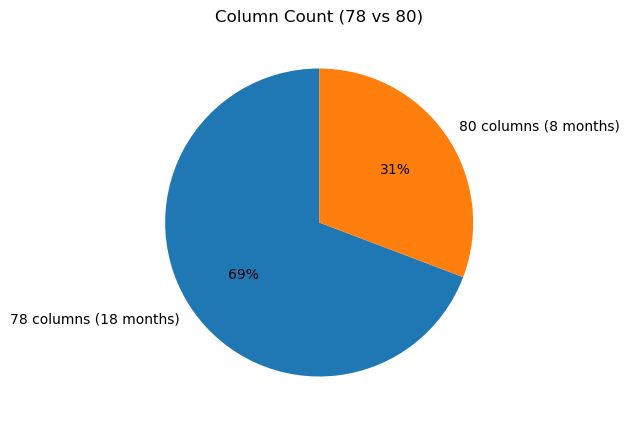

In [11]:
import matplotlib.pyplot as plt

counts = col_counts['n_columns'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts.values,
    labels=[f'{n} columns ({c} months)' for n, c in counts.items()
],
    autopct='%1.0f%%',
    startangle=90,
)
ax.set_title('Column Count (78 vs 80)')
plt.show()

In [12]:
all_cols = sorted(set().union(*schema_by_year_month.values()))
months_sorted = sorted(schema_by_year_month.keys())
columns_existence_per_month = pd.DataFrame(
    { ym: [1 if c in schema_by_year_month[ym] else 0 for c in all_cols] for ym in months_sorted},
    index=all_cols,
)
columns_existence_per_month

,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,...,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
AboveGradeFinishedArea,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFee,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFeeFrequency,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AttachedGarageYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
BasementYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
WaterfrontYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
YearBuilt,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
latfilled,1,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
col_month_counts = pd.Series(
    {c: sum(c in cols for cols in schema_by_year_month.values()) for c in all_cols},
    name='n_months_present'
).sort_values(ascending=False)

col_month_counts

AboveGradeFinishedArea         26
ListAgentEmail                 26
MiddleOrJuniorSchool           26
MainLevelBedrooms              26
MLSAreaMajor                   26
                               ..
lonfilled                       7
BuyerAgencyCompensation         4
BuyerAgencyCompensationType     4
OriginatingSystemSubName        1
OriginatingSystemName           1
Name: n_months_present, Length: 84, dtype: int64

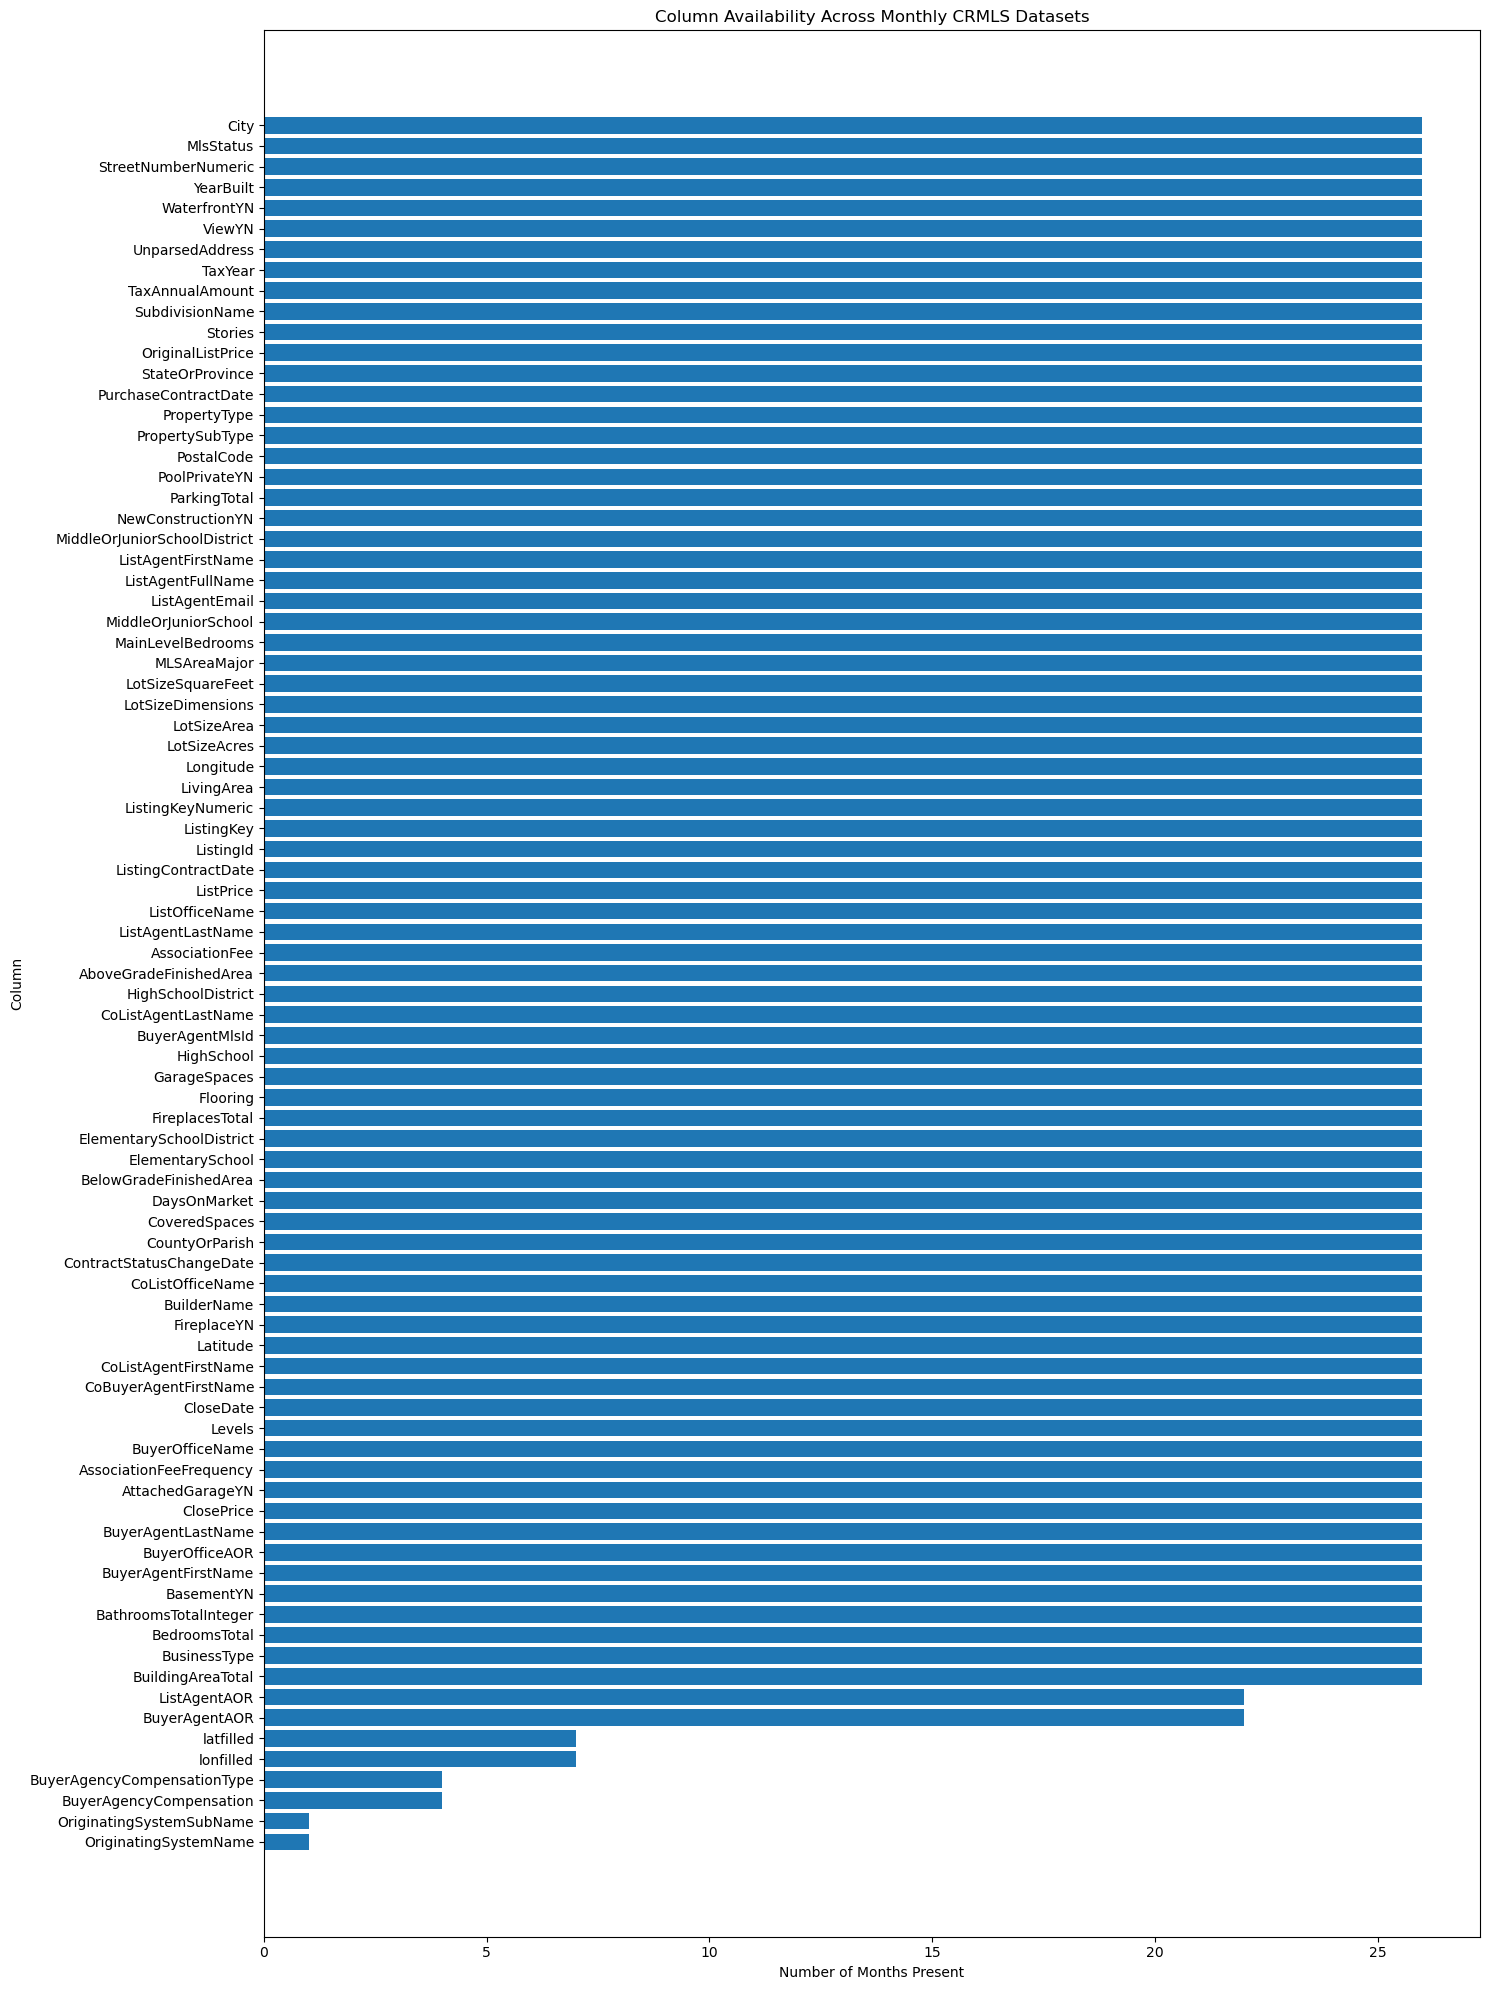

In [14]:
columns_vs_month_count = col_month_counts.sort_values(ascending=True)

plt.figure(figsize=(15, 20))

plt.barh(
    columns_vs_month_count.index,
    columns_vs_month_count.values
)

plt.xlabel("Number of Months Present")
plt.ylabel("Column")
plt.title("Column Availability Across Monthly CRMLS Datasets")

plt.tight_layout()
plt.show()

In [15]:
total_months = len(schema_by_year_month)
print("total months:", total_months)

cols_in_all_months = col_month_counts[col_month_counts == total_months].index
cols_in_all_months

total months: 26


Index(['AboveGradeFinishedArea', 'ListAgentEmail', 'MiddleOrJuniorSchool',
       'MainLevelBedrooms', 'MLSAreaMajor', 'LotSizeSquareFeet',
       'LotSizeDimensions', 'LotSizeArea', 'LotSizeAcres', 'Longitude',
       'LivingArea', 'ListingKeyNumeric', 'ListingKey', 'ListingId',
       'ListingContractDate', 'ListPrice', 'ListOfficeName',
       'ListAgentLastName', 'ListAgentFullName',
       'MiddleOrJuniorSchoolDistrict', 'MlsStatus', 'NewConstructionYN',
       'StreetNumberNumeric', 'YearBuilt', 'WaterfrontYN', 'ViewYN',
       'UnparsedAddress', 'TaxYear', 'TaxAnnualAmount', 'SubdivisionName',
       'Stories', 'OriginalListPrice', 'StateOrProvince',
       'PurchaseContractDate', 'PropertyType', 'PropertySubType', 'PostalCode',
       'PoolPrivateYN', 'ParkingTotal', 'AssociationFee', 'ListAgentFirstName',
       'City', 'BuyerAgentMlsId', 'CloseDate', 'Levels', 'BuyerOfficeName',
       'AssociationFeeFrequency', 'AttachedGarageYN', 'BuyerOfficeAOR',
       'BuyerAgentLastName

#### No Data Type Drift for Each Column

In [16]:
dtype_by_month = apply_per_month(year_month_file_map, lambda f: pd.read_csv(f, low_memory=False).dtypes.astype(str))

dtype_matrix = pd.DataFrame(dtype_by_month).reindex(all_cols)
dtype_matrix.columns = pd.to_datetime(dtype_matrix.columns, format='%Y%m')
dtype_matrix = dtype_matrix.sort_index(axis=1)
dtype_matrix

,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01
AboveGradeFinishedArea,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFee,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFeeFrequency,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
AttachedGarageYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
BasementYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
WaterfrontYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
YearBuilt,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
latfilled,bool,NaN,bool,bool,bool,bool,bool,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
#Find which columns actually drifted:
n_distinct_dtypes = dtype_matrix.apply(lambda row: row.dropna().nunique(), axis=1)
drifted_cols = n_distinct_dtypes[n_distinct_dtypes > 1].sort_values(ascending=False)
drifted_cols

Series([], dtype: int64)

#### General Data Quality

Done:
- count missing values
-  missingness percentage by feature
- investigate whether missingness is systematic
Nice to haves:
- inspect duplicate records
- find ClosePrice <= 0
- look for impossible dates
- check zero/negative LivingArea
- inspect outliers

Making a big dataframe for January 2024 to February 2026

In [18]:
dfs = []
for ym, f in year_month_file_map.items():
    d = pd.read_csv(f, low_memory=False)
    d['year_month'] = pd.to_datetime(ym, format='%Y%m')
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True) # automatically align columns cross months, mising column becomes NaN

In [19]:
df.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,6472.0,NaN,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,52320.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,217364.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,217800.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,0.0,108883.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN


In [20]:
# 
missing_by_month = apply_per_month(
    year_month_file_map,
    lambda f: pd.read_csv(f, low_memory=False).isna().mean() * 100
)
missing_matrix = pd.DataFrame(missing_by_month).reindex(all_cols)
missing_matrix.columns = pd.to_datetime(missing_matrix.columns, format='%Y%m')
missing_matrix = missing_matrix.sort_index(axis=1)
missing_matrix

,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01
AboveGradeFinishedArea,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
AssociationFee,31.646063,30.735257,30.808558,30.320617,31.660815,32.226241,32.168445,31.981432,31.428974,32.461115,...,31.109096,31.543067,31.574051,30.928957,30.588602,30.572892,29.777871,28.556822,30.824286,29.957917
AssociationFeeFrequency,72.530349,70.223338,69.341811,68.441558,69.468041,70.260605,70.426829,70.030133,70.809235,71.160952,...,70.665976,70.790543,71.606191,70.825353,71.011006,70.765721,70.023051,70.255137,72.250864,70.021042
AttachedGarageYN,30.348591,28.271016,27.032136,26.059253,25.831540,26.290694,26.551067,26.981025,26.614003,26.003265,...,28.034033,27.815409,28.093546,27.690232,28.334002,28.132398,27.870914,29.477067,30.618063,29.331931
BasementYN,98.524335,98.519448,98.543564,98.400974,98.259524,98.557218,98.155488,98.257187,98.189684,98.161038,...,98.393366,98.186427,98.388734,98.415462,98.413759,98.196531,98.161148,98.446782,98.562504,98.453446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,9.800646,9.661230,9.481870,9.590097,10.046438,9.988491,9.710366,10.261422,10.429304,10.956432,...,9.950764,10.370144,10.035524,10.047014,10.319476,10.825119,10.409681,10.604733,9.152666,9.605471
WaterfrontYN,99.944315,99.924718,99.948445,99.935065,99.966021,99.946564,99.935213,99.967424,99.967085,99.965627,...,99.930897,99.934449,99.949251,99.960822,99.968810,99.944045,99.984283,99.926965,99.927215,99.910573
YearBuilt,5.201025,5.109159,4.545455,4.606331,4.236040,4.024170,3.746189,3.994625,3.752292,3.312709,...,4.396649,4.081633,3.704643,3.687097,4.014615,3.860888,3.939648,4.601227,4.652150,4.550237
latfilled,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
overall_missing_by_month = missing_matrix.mean(axis=0, skipna=True)
overall_missing_by_month.name = 'pct_missing'

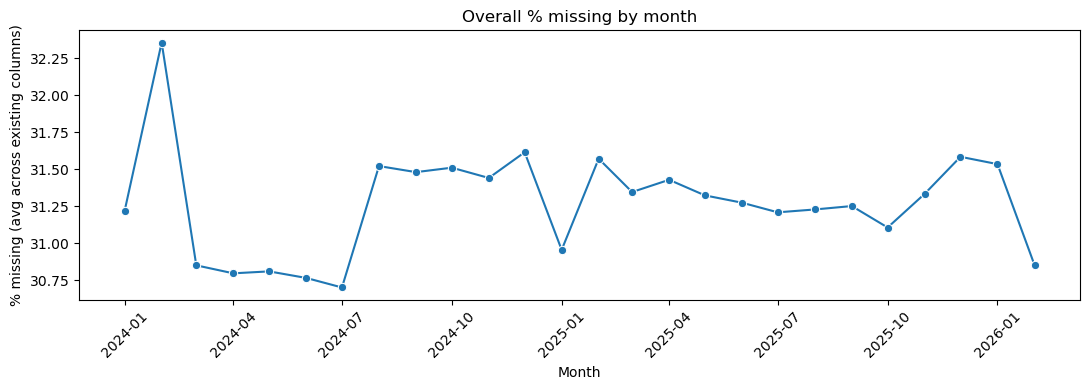

In [22]:
import seaborn as sns 

missing_trend = overall_missing_by_month.reset_index()
missing_trend.columns = ['year_month', 'pct_missing']

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=missing_trend, x='year_month', y='pct_missing', marker='o', ax=ax)
ax.set_title('Overall % missing by month')
ax.set_ylabel('% missing (avg across existing columns)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
missing_by_feature = missing_matrix.mean(axis=1, skipna=True).sort_values(ascending=False)
nonzero = missing_by_feature[missing_by_feature > 0] # actually missing

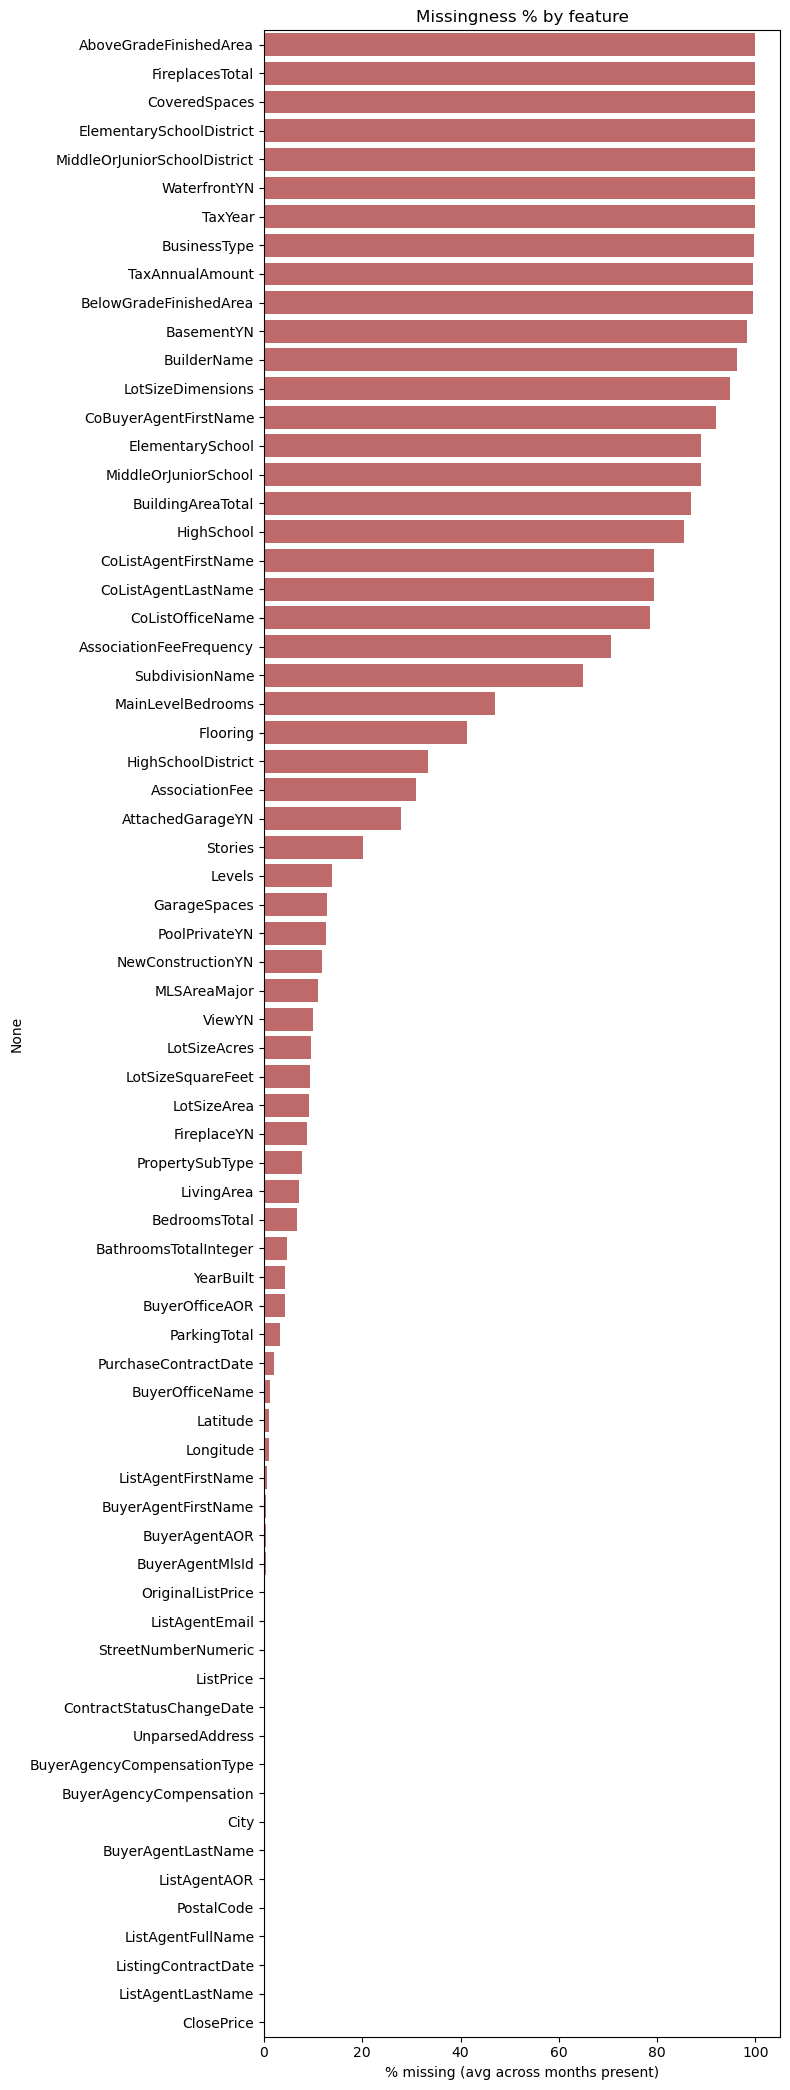

In [24]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(nonzero))))
sns.barplot(x=nonzero.values, y=nonzero.index, color='indianred', ax=ax)
ax.set_xlabel('% missing (avg across months present)')
ax.set_title('Missingness % by feature')
plt.tight_layout()
plt.show()

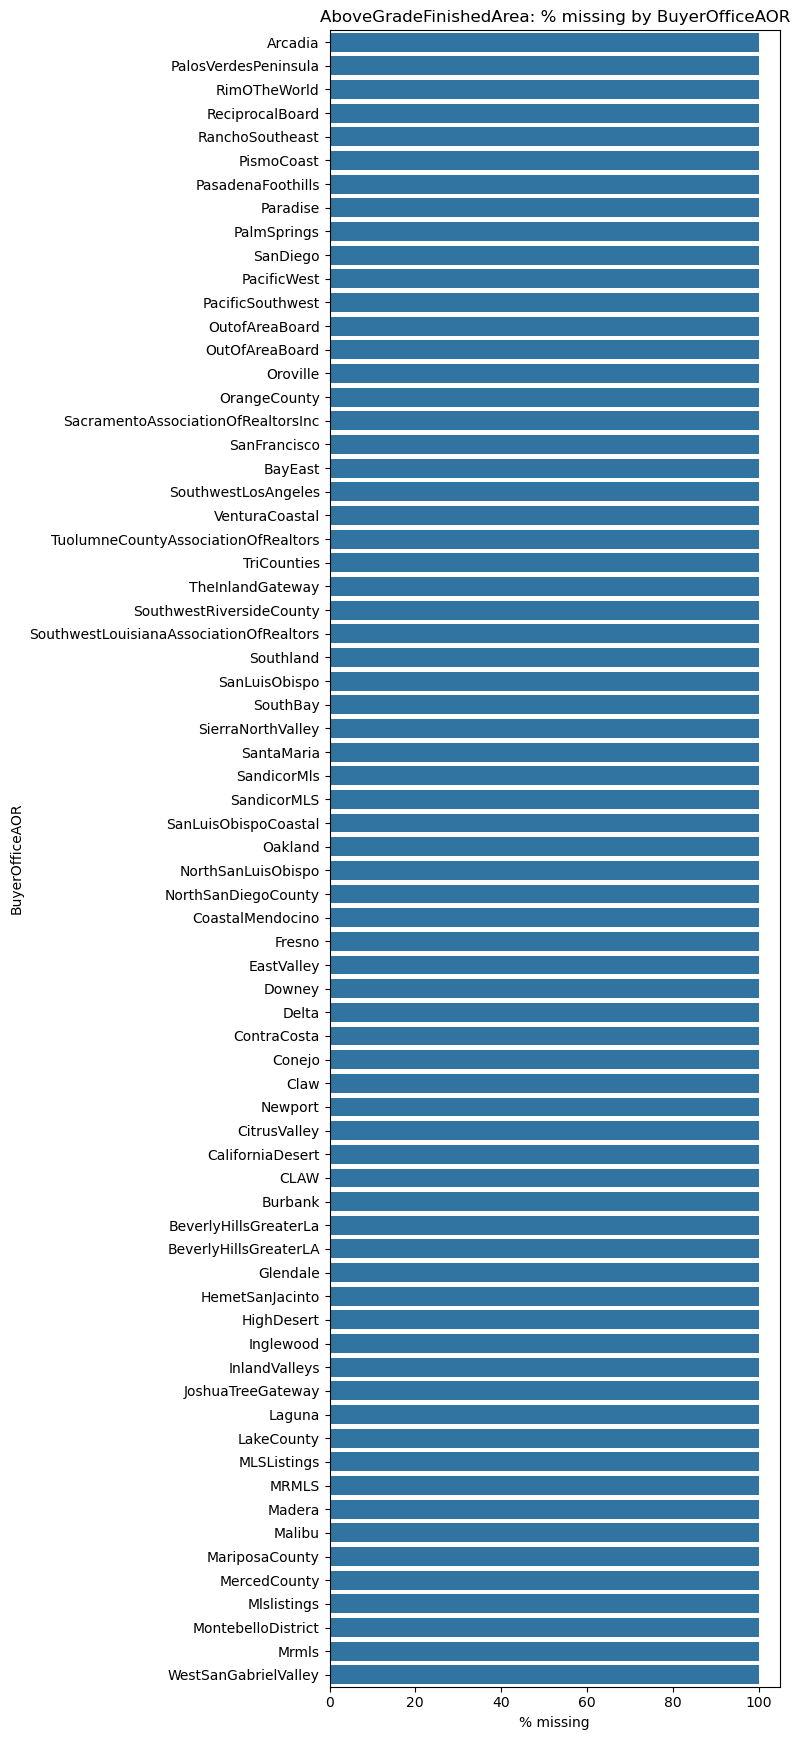

In [25]:
col = 'AboveGradeFinishedArea'  # swap in whatever feature you're checking

missing_by_buyer_offic_board = (
    df.groupby('BuyerOfficeAOR')[col]
    .apply(lambda s: s.isna().mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(missing_by_buyer_offic_board))))
sns.barplot(x=missing_by_buyer_offic_board.values, y=missing_by_buyer_offic_board.index, ax=ax)
ax.set_xlabel('% missing')
ax.set_title(f'{col}: % missing by BuyerOfficeAOR')
plt.tight_layout()
plt.show()

Investingating Duplicate Rows

In [26]:
exact_dupes = df[df.duplicated(keep=False)]
len(exact_dupes)

272

In [27]:
dupe_keys = df[df.duplicated(subset='ListingKey', keep=False)]
dupe_keys.sort_values('ListingKey').head(20)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
309924,Wood,False,NaN,NaN,False,4500.0,443852184,Carla@PacificShoreProperties.com,2025-03-26,5200.0,...,0.0,NaN,NaN,NaN,NaN,2025-03-01,SanDiego,SanDiego,NaN,NaN
37908,Wood,False,NaN,NaN,False,4500.0,443852184,Carla@PacificShoreProperties.com,2024-03-01,5050.0,...,0.0,NaN,NaN,True,True,2024-03-01,NaN,NaN,NaN,NaN
162869,NaN,False,NaN,NaN,NaN,471000.0,447019589,Frank@NorCalEmail.com,2024-08-01,235224.0,...,0.0,78408.0,NaN,NaN,NaN,2024-08-01,SierraNorthValley,SierraNorthValley,NaN,NaN
162868,NaN,False,NaN,NaN,NaN,471000.0,447019589,Frank@NorCalEmail.com,2024-08-01,235224.0,...,0.0,78408.0,NaN,NaN,NaN,2024-08-01,SierraNorthValley,SierraNorthValley,NaN,NaN
162866,NaN,False,NaN,NaN,NaN,419000.0,447019590,Frank@NorCalEmail.com,2024-08-01,209088.0,...,0.0,69696.0,NaN,NaN,NaN,2024-08-01,SierraNorthValley,SierraNorthValley,NaN,NaN
162867,NaN,False,NaN,NaN,NaN,419000.0,447019590,Frank@NorCalEmail.com,2024-08-01,209088.0,...,0.0,69696.0,NaN,NaN,NaN,2024-08-01,SierraNorthValley,SierraNorthValley,NaN,NaN
532573,"Tile,Wood",True,NaN,NaN,False,2850.0,497708816,mjmatson@gmail.com,2025-12-16,3650.0,...,0.0,NaN,NaN,NaN,NaN,2025-12-01,SanDiego,SanDiego,NaN,NaN
61170,"Tile,Wood",True,NaN,NaN,False,2850.0,497708816,mjmatson@gmail.com,2024-04-24,3300.0,...,0.0,NaN,NaN,True,True,2024-04-01,NaN,NaN,NaN,NaN
162861,NaN,True,NaN,NaN,NaN,24500.0,510488601,ann@anntrussell.com,2024-08-16,12500.0,...,0.0,24790.0,NaN,NaN,NaN,2024-08-01,Southland,Southland,NaN,NaN
231960,NaN,True,NaN,NaN,NaN,24500.0,510488601,ann@anntrussell.com,2024-11-05,12500.0,...,0.0,24790.0,NaN,NaN,NaN,2024-11-01,Southland,Southland,NaN,NaN


In [ ]:
# dupe_summary = (
#     dupe_keys
#     .groupby('ListingKey')['year_month']
#     .agg(['nunique', 'count'])
#     .sort_values('count', ascending=False)
# )
# dupe_summary # what does this tell us?

,nunique,count
ListingKey,,
1137587745,1,4
1137587664,1,4
1137587630,1,4
1137587665,1,4
1090159253,3,3
...,...,...
1075235304,2,2
1075214198,2,2
1075200385,1,2


Likely: AboveGradeFinishedArea / BelowGradeFinishedArea are part of the RESO MLS data standard's basement-distinction fields standard for Midwest and Northeast. California housing stock rarely has basements, and CRMLS input forms likely don't even surface these fields to agents as something to fill in, even though the column exists in the schema. So it's not "missing data" in the sense of a reporting gap.

#### Understand What We Want to Predict: ClosePrice

We want to use data science, perhaps even some reference to previous similar work, to accurately and reliable predict the closePrice.

Noteworthy background:

- Hedonic pricing theory (Rosen, 1974, "Hedonic Prices and Implicit Markets", JPE) is the foundational justification for predicting price from property characteristics (sqft, bedrooms, location) in the first place. It's the theoretical basis for the whole feature set to be built (LivingArea, BedroomsTotal, geography, etc.).
- De Cock (2011), "Ames, Iowa: Alternative to the Boston Housing Data..." (Journal of Statistics Education) is the standard pedagogical reference for right-skewed house prices, outliers from unusual sales, and the now-standard practice of modeling log(SalePrice) rather than raw price. It's the source dataset behind the Kaggle "House Prices" competition, and the skew/log-transform diagnostic presented in the work.
- Since errors are multi-scale (a $50K miss means something very different on a $200K condo vs a $3M home), percentage-based metrics (MAPE/MdAPE) or RMSE computed in log-space are preferred over raw RMSE/MAE. This reflects how Zillow publicly reports Zestimate accuracy using median absolute percentage error, precisely because raw dollar error isn't comparable across the price spectrum.

In [28]:
# TODO: 
#  df["ClosePrice"].describe()
# sns.histplot(df["ClosePrice"], bins=50)
# sns.histplot(np.log1p(df["ClosePrice"]), bins=50) (using bins)

In [ ]:
#1. Run describe(), but also quantify the skew numerically (visually "looks skewed" isn't rigorous enough to act on):

df['ClosePrice'].describe()

print('skew:', df['ClosePrice'].skew())
print('kurtosis:', df['ClosePrice'].kurt())

#A skew well above 0 (real estate prices commonly land in the 2–5+ range) combined with mean >> median in .describe() output confirms a long right tail — a handful of luxury sales pulling the mean up.

#2. Check the log-transformed version too — this is the standard move in house-price modeling (more on why below):

log_price = np.log1p(df['ClosePrice'])
print('log skew:', log_price.skew())
print('log kurtosis:', log_price.kurt())
log_price.describe()

#If skew drops close to 0 after the log transform, that's evidence ClosePrice is closer to log-normal than normal — which should inform whether you model ClosePrice directly or log(ClosePrice).

#3. Visualize both, which your notebook already stubbed:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ClosePrice'], bins=50, ax=axes[0]); axes[0].set_title('ClosePrice')
sns.histplot(log_price, bins=50, ax=axes[1]); axes[1].set_title('log1p(ClosePrice)')
plt.tight_layout()
plt.show()

#4. Boxplot to visually confirm the luxury-home tail, and check for ClosePrice <= 0 (your next TODO item) since those are almost certainly data errors, not real sales (e.g. the $950 row you saw earlier in df_2024_01 — a transfer/placeholder, not a market transaction):

(df['ClosePrice'] <= 0).sum()

Also use a boxplot.
You're likely investigating:
- right skew
- luxury-home tail
- extreme transactions
- whether variance increases with price
This matters because the handbook specifically describes real-estate prices and errors as multi-scale and right-skewed, which is one reason it emphasizes percentage-based metrics such as MdAPE

#### Numeric variables

Then analyze things like:
- LivingArea
- LotSizeSquareFeet
- BedroomsTotal
- BathroomsTotalInteger
- YearBuilt
- TaxAnnualAmount
- Stories
- FireplacesTotal

distribution
missing %
zero / impossible values
outliers
unique values

#### Geography
Location is one of the major predictive feature families.

Median ClosePrice by:
- City
- ZIP
- MLS area
- school district

| ZIP | Sales | Median ClosePrice | Median $/sqft |
|---|---:|---:|---:|
| ... | ... | ... | ... |
| ... | ... | ... | ... |

### Geographical Interactions
- LivingArea vs geography
- Plot median price vs. living area separately for several cities.

#### Categorical 

categorical_summary = pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(),
    "missing_pct": df[categorical_cols].isna().mean() * 100
}).sort_values("n_unique", ascending=False)